In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
#load data

In [ ]:
iris = load_iris()

In [ ]:
#create dataframe

In [ ]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
X = iris.data
df.sample(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
23,5.1,3.3,1.7,0.5,0
77,6.7,3.0,5.0,1.7,1
105,7.6,3.0,6.6,2.1,2
109,7.2,3.6,6.1,2.5,2


In [ ]:
#elbow methhod to find optimal cluster (k) number

In [ ]:
distortions = []
for i in range(1, 11):
    km = KMeans(
        n_clusters=i, init='random',
        n_init=10, max_iter=300,
        tol=1e-04, random_state=0
    )
    km.fit(X)
    distortions.append(km.inertia_)



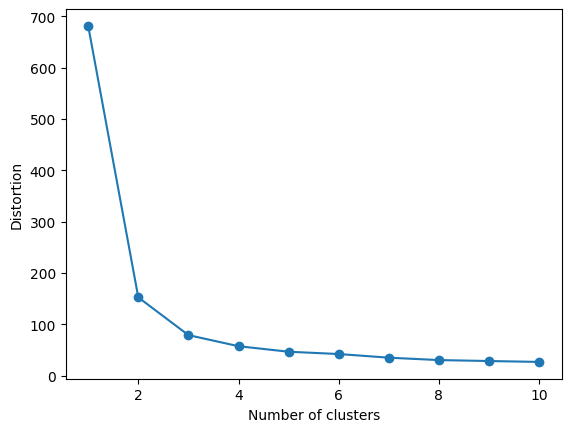

In [ ]:
# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [ ]:
distortions=distortions/np.max(distortions)
distortions
#np.size(distortions)

array([1.        , 0.22359044, 0.11572475, 0.08399023, 0.06816581,
       0.06159095, 0.05113992, 0.04430052, 0.04158307, 0.03902488])

In [ ]:

for i in range(np.size(distortions)):
  print(distortions[i])
  if((distortions[i]-distortions[i+1])<.1):
    break
k=i+1
k

1.0
0.2235904392710194
0.1157247486553515


3

In [ ]:
#instantiat Kmeans


In [ ]:
km = KMeans(k)
clusts = km.fit_predict(X)

In [ ]:
#plot the cluster

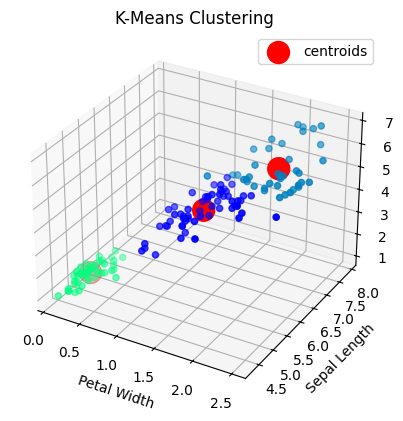

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(km.cluster_centers_[:, 3],
            km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 2],
            s = 250,
            marker='o',
            c='red',
            label='centroids')
scatter = ax.scatter(df['petal width (cm)'],df['sepal length (cm)'], df['petal length (cm)'],
                     c=clusts,s=20, cmap='winter')


ax.set_title('K-Means Clustering')
ax.set_xlabel('Petal Width')
ax.set_ylabel('Sepal Length')
ax.set_zlabel('Petal Length')
ax.legend()
plt.show()